In [2]:
# Importing packages and setting up the formatting of figures. 

import numpy as np
import pandas as pd

# APIs
from fredapi import Fred
from dstapi import DstApi

# plotting
import matplotlib.pyplot as plt
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'--'})
plt.rcParams.update({'font.size': 14})

In [3]:
# Getting an overview of the available data in table IFOR41.
IFOR41 = DstApi('IFOR41')
IFOR41.tablesummary(language='en')

Table IFOR41: Income distribution on equivalised disposable income by indicator, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,ULLIG,4,70,Gini coefficient,73,P90/10 (Upper decile boundary divided by lower),False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [4]:
# Finding the appropriate variable (Gini coefficient) levels for the variable ULLIG in table IFOR41.
IFOR41.variable_levels('ULLIG',language='en')

,id,text
0,70,Gini coefficient
1,71,Hoover index
2,72,S80/S20 (Income quintile share ratio)
3,73,P90/10 (Upper decile boundary divided by lower)


In [5]:
# a. Downloading the gini parameter for all of denmark  
params = {
    'table': 'IFOR41',
    'format': 'BULK', # semicolon separated file
    'lang': 'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},
        {'code': 'KOMMUNEDK', 'values': ['000']},
        {'code': 'TID', 'values': ['*']}, # '*' is everything
        ]
    }

# b. download
gini = IFOR41.get_data(params=params)


# c. display
display(gini.head(5))
display(gini.info())

,ULLIG,KOMMUNEDK,TID,INDHOLD
0,Gini coefficient,All Denmark,2016,28.97
1,Gini coefficient,All Denmark,1999,23.83
2,Gini coefficient,All Denmark,1988,22.06
3,Gini coefficient,All Denmark,2015,28.77
4,Gini coefficient,All Denmark,1989,21.93


<class 'pandas.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ULLIG      38 non-null     str  
 1   KOMMUNEDK  38 non-null     str  
 2   TID        38 non-null     int64
 3   INDHOLD    38 non-null     str  
dtypes: int64(1), str(3)
memory usage: 2.5 KB


None

In [6]:
def load_IFOR41(ULLIG,KOMMUNEDK,TID,varname):

    params = {
        'table': 'IFOR41',
        'format': 'BULK', # semicolon separated file
        'lang': 'en',
        'variables': [
            {'code': 'ULLIG', 'values': ['70']},
            {'code': 'KOMMUNEDK', 'values': ['000']},
            {'code': 'TID', 'values': ['*']},
            ]
    }    

    # b. download
    df = DstApi('IFOR41').get_data(params=params)

    # c. set types and rename
    df['INDHOLD'] = df['INDHOLD'].astype(float)
    df = df.drop(columns=['ULLIG'])
    df = df.rename(columns={'INDHOLD': 'Gini Coefficient', 'TID': 'year'})
    df = df.set_index('year').sort_index()
    
    return df

gini_df = load_IFOR41('70', '000', '*', 'gini')

# Vis de første 5 rækker
print(gini_df.head())

        KOMMUNEDK  Gini Coefficient
year                               
1987  All Denmark             22.07
1988  All Denmark             22.06
1989  All Denmark             21.93
1990  All Denmark             22.16
1991  All Denmark             21.99


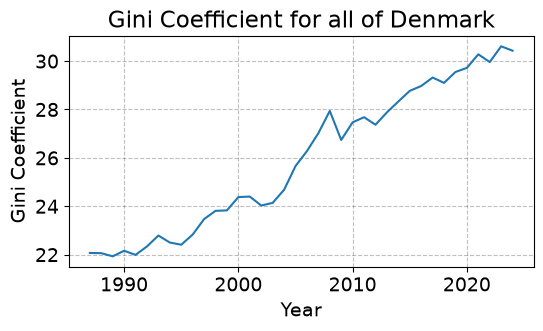

In [9]:
# Creating the plot for the Gini coefficient over time for all municipalities in Denmark.
import matplotlib.pyplot as plt
    
for col in ['Gini Coefficient']:
    fig = plt.figure(figsize=(6,3))
    ax = fig.add_subplot(111)
    
    ax.plot(gini_df.index, gini_df[col])
    
    ax.set_title('Gini Coefficient for all of Denmark')
    ax.set_xlabel('Year')
    ax.set_ylabel('Gini Coefficient')

plt.show()

Problem 2) 


2.1) The model is constructed in the attached .py file and imported into the notebook for simulation.



In [9]:
# ensuring that all updates to the file model is loaded into the notebook when importing:
%load_ext autoreload
%autoreload 2

# Importing the life cycle model from the p2_model.py file:
from p2_model import life_cycle_model

# running the model itself:
model = life_cycle_model()
model.sim_life_cycle_model()



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Printing the simulation and analyzing the sanity checks:

In [12]:
import numpy as np

# Printing the raw simulation for the first 5 people and first 6 ages:
print("income shape:", model.income.shape)   
print(model.income[:5, :6].round(2))        

# First sanity check by making sure that the education shares matches the education probabilities:
print("education shares:", np.round(np.bincount(model.education, minlength=3)/model.N, 4))

# Second sanity check that unemployment matches the SS value at sigma/(sigma+lambda):
late = [np.mean(model.status[model.status[:,t] >= 0, t] == 0) for t in range(model.T-10, model.T)]
print("unemployment ages 55-64:", round(np.mean(late), 4),
      "  steady state:", round(model.sigma/(model.sigma+model.lam), 4))

income shape: (50000, 47)
[[0.45 0.35 1.03 1.17 1.16 1.13]
 [0.45 0.45 0.45 0.35 1.2  1.16]
 [0.45 0.45 0.45 0.35 0.82 0.77]
 [0.45 0.35 0.35 0.74 0.74 0.7 ]
 [0.45 0.35 0.35 0.83 0.8  0.84]]
education shares: [0.4026 0.3515 0.2459]
unemployment ages 55-64: 0.0911   steady state: 0.0909


Time series plot and histogram


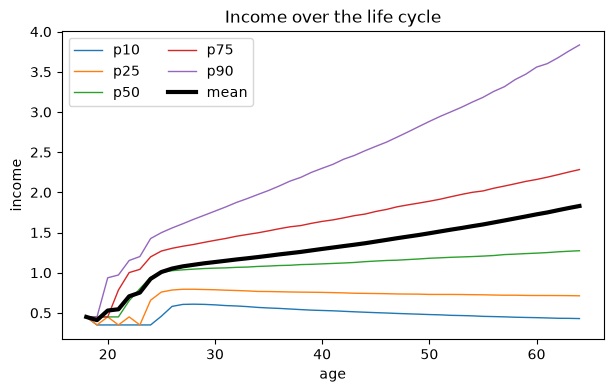

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

ages = np.arange(model.age_start, model.age_retire)   # 18..64

# mean and percentiles across the simualtion:
mean_income = model.income.mean(axis=0)
pcts = [10, 25, 50, 75, 90]
P = np.percentile(model.income, pcts, axis=0)        

fig = plt.figure(figsize=(7, 4))
ax = fig.add_subplot(1, 1, 1)
for i, p in enumerate(pcts):
    ax.plot(ages, P[i], lw=1, label=f'p{p}')
ax.plot(ages, mean_income, lw=3, color='black', label='mean')
ax.set_xlabel('age')
ax.set_ylabel('income')
ax.set_title('Income over the life cycle')
ax.legend(ncol=2)

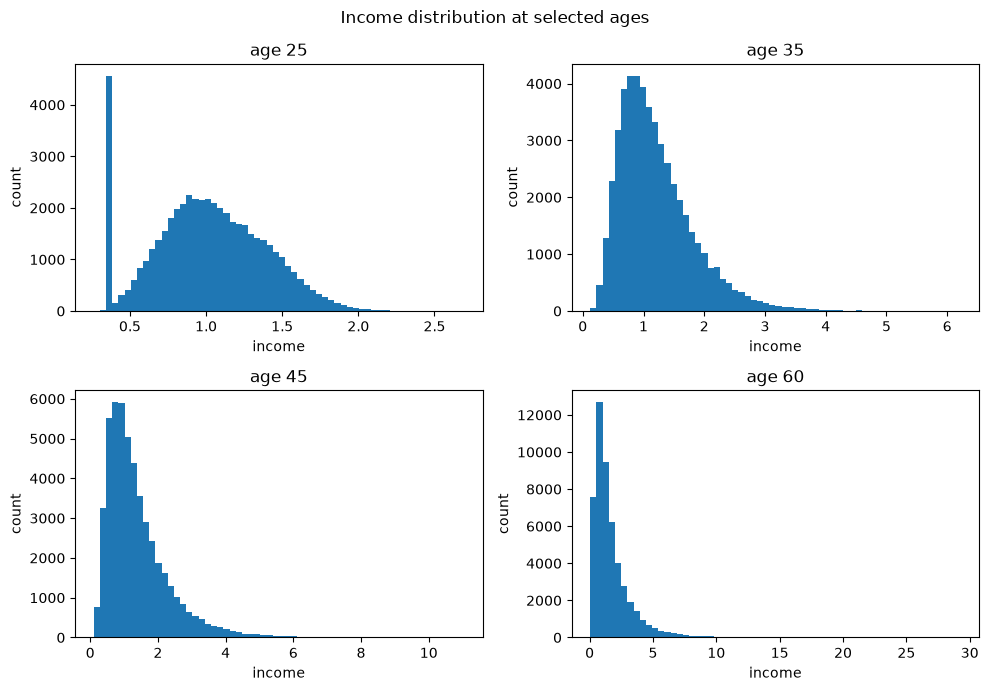

In [ ]:
# histogram over the income distribution at selected ages: 
fig = plt.figure(figsize=(10, 7))
for i, age in enumerate([25, 35, 45, 60]):
    ax = fig.add_subplot(2, 2, i + 1)
    ax.hist(model.income[:, age - model.age_start], bins=60)
    ax.set_title(f'age {age}')
    ax.set_xlabel('income')
    ax.set_ylabel('count')
fig.suptitle('Income distribution at selected ages')
fig.tight_layout()

In [ ]:
# EXERCISE 1.2: Prediction 
